In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

daily = pd.read_parquet(project_root / "data" / "processed" / "daily_metrics.parquet")
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values(['Account', 'date']).copy()
print("Data loaded. Shape:", daily.shape)

Data loaded. Shape: (102, 13)


In [2]:
# Create lagged features
for lag in [1, 2, 3]:
    daily[f'prev_{lag}_pnl'] = daily.groupby('Account')['daily_pnl'].shift(lag)
    daily[f'prev_{lag}_win_rate'] = daily.groupby('Account')['win_rate'].shift(lag)
    daily[f'prev_{lag}_leverage'] = daily.groupby('Account')['avg_leverage'].shift(lag)
    daily[f'prev_{lag}_trades'] = daily.groupby('Account')['trade_count'].shift(lag)

# Encode sentiment
daily['sentiment_numeric'] = daily['classification'].map({'Fear': 0, 'Greed': 1})

# Drop rows with missing lagged values
model_data = daily.dropna(subset=['prev_1_pnl', 'sentiment_numeric']).copy()
print("Model ready data shape:", model_data.shape)

Model ready data shape: (63, 26)


In [5]:
# Features already exist (lags), now add target as next day PnL
model_data['next_day_pnl'] = model_data.groupby('Account')['daily_pnl'].shift(-1)

# Define feature columns
feature_cols = [
    'prev_1_pnl', 'prev_1_win_rate', 'prev_1_leverage', 'prev_1_trades',
    'sentiment_numeric', 'avg_leverage'
]

# Create a clean dataframe with features and target
model_df = model_data[feature_cols + ['next_day_pnl']].dropna()
print(f"After dropping rows with missing values: {model_df.shape}")

# Features and target
X = model_df[feature_cols]
y = model_df['next_day_pnl']

print(f"X shape: {X.shape}, y shape: {y.shape}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred = rf_reg.predict(X_test)

print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²: {rf_reg.score(X_test, y_test):.4f}")

# Cross-validation
cv_scores = cross_val_score(rf_reg, X, y, cv=5, scoring='r2')
print(f"Cross-validated R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

After dropping rows with missing values: (32, 7)
X shape: (32, 6), y shape: (32,)
RMSE: $124170.67
R²: -2.1260
Cross-validated R²: -0.8819 (+/- 1.0249)


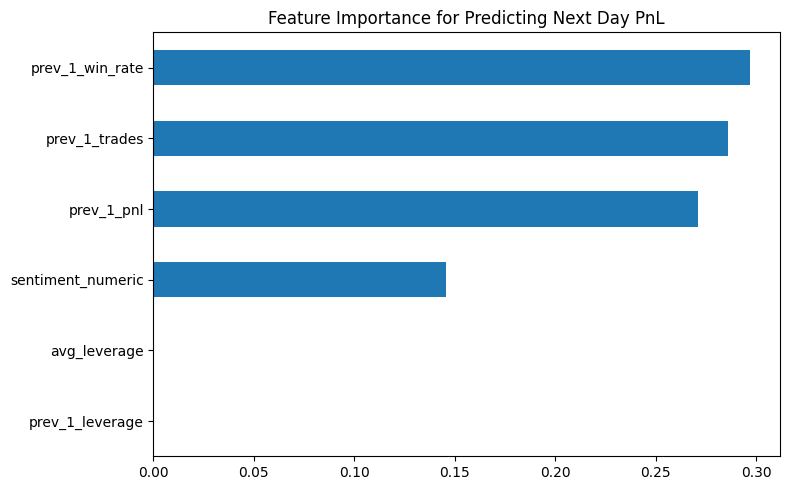

In [6]:
# Feature importance
importances = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.title('Feature Importance for Predicting Next Day PnL')
plt.tight_layout()
plt.show()

In [7]:
# Classification: will next day PnL be positive?
y_class = (y > 0).astype(int)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)
y_pred_c = rf_clf.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c))

Accuracy: 0.7142857142857143

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.71      1.00      0.83         5

    accuracy                           0.71         7
   macro avg       0.36      0.50      0.42         7
weighted avg       0.51      0.71      0.60         7



C:\Users\naval\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\naval\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\naval\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
# Add lagged sentiment and re-run (optional)
model_data['prev_sentiment'] = model_data.groupby('Account')['sentiment_numeric'].shift(1)
X2 = model_data[feature_cols + ['prev_sentiment']].dropna()
y2 = model_data.loc[X2.index].groupby('Account')['daily_pnl'].shift(-1).dropna()
print("With prev_sentiment, X shape:", X2.shape)

With prev_sentiment, X shape: (32, 7)


In [9]:
# Save model for dashboard
import joblib
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)
joblib.dump(rf_reg, models_dir / "pnl_predictor.pkl")
print("Model saved to models/pnl_predictor.pkl")

Model saved to models/pnl_predictor.pkl


C:\Users\naval\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,avg_leverage,trade_count,win_rate,daily_pnl
cluster,,,,
0,1.0,1968.243243,0.278940,90757.143026
1,1.0,23920.500000,0.426198,533562.594424
2,1.0,700.400000,0.715120,100552.206828
3,1.0,223.000000,0.000000,0.000000


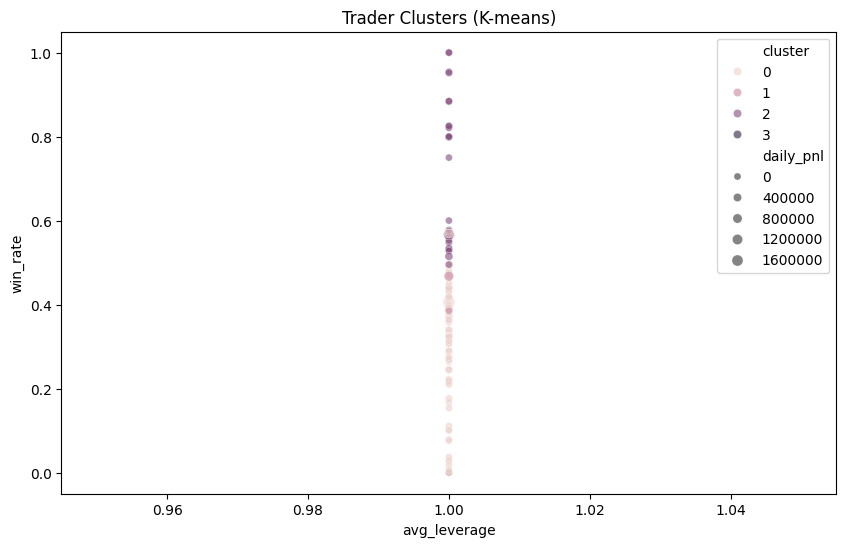

In [10]:
# Clustering traders (bonus)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = daily[['avg_leverage', 'trade_count', 'win_rate', 'long_short_ratio']].dropna()
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
daily['cluster'] = kmeans.fit_predict(scaled)

# Analyze clusters
cluster_summary = daily.groupby('cluster')[['avg_leverage', 'trade_count', 'win_rate', 'daily_pnl']].mean()
display(cluster_summary)

# Visualize clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=daily, x='avg_leverage', y='win_rate', hue='cluster', size='daily_pnl', alpha=0.6)
plt.title('Trader Clusters (K-means)')
plt.show()